# Replication: *Moments by Integrating the Moment-Generating Function*

Single notebook that reproduces every figure and table in the paper and its Supplement, in the order they appear. Code is taken from the author's working notebooks; figures render inline.

**Map of deliverables**

| Paper item | What it shows | Method |
|---|---|---|
| **Figure 1** | NIG densities (left) and complex-MGF contour $t\mapsto M_X(1+it)$ (right) | — |
| **Figure 2** | NIG absolute moments $\mathbb{E}\lvert X\rvert^{r}$ vs. simulation, plus accurate-decimals panel | Thm 1 |
| **Figure 3** | Conditional fractional moments $\mathbb{E}[X^{r}\mid X>0]$ of two compound Poisson-Gamma laws | Thm 1 |
| **Supp. Figure** | NIG integrand profiles (CMGF vs. density) | — |
| **Supp. Table 1** | CMGF timing for $\mathbb{E}\lvert X\rvert^{r}$, $X\sim$ NIG | Thm 1 |
| **Supp. Table 2** | $\chi^{2}_{8}$ parabolic-representation verification | Thm 4 / Cor 3 |

`FractionalMomentsPoisson.ipynb` (Heston-Nandi GARCH) is not used in the paper and is omitted. _Kernel: Julia 1.12._

In [1]:
using Distributions, Random, Statistics, Plots, QuadGK, ForwardDiff,
      LinearAlgebra, LaTeXStrings, SpecialFunctions, BenchmarkTools, Printf

Random.seed!(2026)   # added for reproducibility of the Monte Carlo panels

TaskLocalRNG()

# Part I — Main Text

## Section 3.1 — Normal-Inverse Gaussian (NIG)

# Normal-Inverse Gaussian Distribution
The normal-inverse Gaussian distribution (NIG) has four parameters, $\lambda$ (location),
$\delta$ (scale), 
$\alpha $ (tail heaviness), and 
$\beta$ (asymmetry),  and its density is given by
$$
f(x)=\frac{\alpha \delta K_1 \left( \alpha \sqrt{\delta^2 + (x - \lambda)^2} \right)}{\pi \sqrt{\delta^2 + (x - \lambda)^2}} e^{\delta \gamma + \beta (x - \lambda)},
$$
where $K_1(\cdot)$ denotes the modified Bessel function of the second kind, and $\gamma = \sqrt{\alpha^2 - \beta^2}$ is a (redundant) auxiliary parameter that simplifies expressions.

The Moment-Generating Function (MGF) is given by
$$
\operatorname{MGF}(z)=e^{\lambda z + \delta \left( \gamma - \sqrt{\alpha^2 - (\beta + z)^2} \right)}.
$$
## Standardized NIG

The standardized NIG distribution has mean zero and variance one, which is acheived with
$$
\delta = \frac{\gamma^3}{\alpha^2} \quad \text{and} \quad \lambda = - \frac{\delta \beta}{\gamma}
$$
The standardized distribution can be characterized by two parameters $(\xi,\chi)$, $$
\xi = \frac{1}{\sqrt{1 + \delta \gamma}} \quad \text{and} \quad \chi = \xi \frac{\beta}{\alpha}.
$$
with domain $ 0\leq |\chi| \leq \xi <1. $


The corresponding NIG parameters are given by
$$
\lambda = - \nu\varrho\quad 
\delta = \nu\sqrt{1-\varrho^2}\quad 
\alpha = \frac{\nu}{1-\varrho^2}\quad 
\beta = \frac{\varrho\nu}{1-\varrho^2}\quad 
\gamma = \frac{\nu}{\sqrt{1-\varrho^2}}.
%\lambda = - \chi\frac{\sqrt{1-\xi^2}}{\xi^2}\quad 
%\delta = \sqrt{\xi^2-\chi^2}\frac{\sqrt{1-\xi^2}}{\xi^2}\quad 
%\alpha = \frac{\xi \sqrt{1 - \xi^2}}{\xi^2 - \chi^2}\quad 
%\beta = \frac{\chi \sqrt{1 - \xi^2}}{\xi^2 - \chi^2}\quad 
%\gamma = \sqrt{\frac{1 - \xi^2}{\xi^2 - \chi^2}},
$$ 
where $\nu=\sqrt\frac{1-\xi^2}{\xi^2}$ and $\varrho=\chi/\xi$ is an alternative parametrization, $\varrho\in (-1,1)$ and $\nu\in \mathbb{R}_+$.

For this parametrization, skewness is $3\frac{\varrho}{1-\varrho^{2}}\sqrt{1+\nu^{2}}$ and kurtosis is $3+3\frac{1+4\varrho^{2}}{\nu^{2}}$.

In [2]:
# Parameters for standardized NIG (has mean zero and variance 1)
# Characterized by (ξ,χ),  0 ≤ |χ| < ξ < 1
function sNIG(ξ,χ)
    ν  =  √(1-ξ^2)/ξ; ϱ  =  χ/ξ  # auxiliary parameters for simpler expressions
    λ  = -ν*ϱ; δ = ν*√(1-ϱ^2); α = ν/(1-ϱ^2); β = ν*ϱ/(1-ϱ^2); γ = ν/√(1-ϱ^2)
    # α = ξ*√(1-ξ^2)/(ξ^2-χ^2); β = χ*√(1-ξ^2)/(ξ^2-χ^2); γ = √((1-ξ^2)/(ξ^2-χ^2)); δ = γ^3/α^2; λ = - δ*β/γ
    return(λ, α, β, δ, γ)
end
# Moment-Generating Function for NIG
function MGF_NIG(λ, α, β, δ, γ, z)
    return exp(λ*z + δ*(γ-√(α^2 - (β+z)^2)))
end
# Density of NIG
function pdf_NIG(λ, α, β, δ, γ, t)
    return α*δ*besselk(1,α*√(δ^2+(t-λ)^2))/(π*√(δ^2+(t-λ)^2))*exp(δ*γ+β*(t-λ))
end

pdf_NIG (generic function with 1 method)

## New Methods for Computing Absolute Moments

In [3]:
# New Integral Expression for Evaluating Real Absolute Moments
# Theorem 1
function CMGF_NIG(s, λ, α, β, δ, γ, r)
    g(t) = real((MGF_NIG(λ, α, β, δ, γ, s+im*t)+ MGF_NIG(λ, α, β, δ, γ, -s-im*t))/(s+im*t)^(r+1))
    integral, err = quadgk(t -> g(t), 0, Inf, rtol=1e-8)
    return gamma(r+1)*integral/π
end
# New Integral Expression for Evaluating INTEGER Moments
# Theorem 3
function CMGF3_NIG(s, λ, α, β, δ, γ, k)
    g(t) = real((MGF_NIG(λ, α, β, δ, γ, s+im*t)+(-1)^k *MGF_NIG(λ, α, β, δ, γ, -s-im*t))/(s+im*t)^(k+1))
    integral, err = quadgk(t -> g(t), 0, Inf, rtol=1e-8)
    return factorial(k)*integral/π
end

CMGF3_NIG (generic function with 1 method)

## Integrate with Density

In [4]:
# Direct integration of |x|^r*f(x)
function mPDF_NIG(λ, α, β, δ, γ, r)
    f(x) = pdf_NIG(λ, α, β, δ, γ, x)*abs(x).^r #* 
    integral, err = quadgk(x -> f(x), -25.0, 100, rtol=1e-8)        # A bit unstable and endpoint (Inf does not work)
    return integral
end

mPDF_NIG (generic function with 1 method)

## Simulation Method: Average of N draws

In [5]:
# This is the function for simulating moments
# r: Estimates the r'th absolute momemnt
# N: Number of random variables to average over
function MomentSimNIG(λ, α, β, δ, γ, r, N)
    NIGdist = NormalInverseGaussian(λ, α, β, δ)
    X       = [abs(rand(NIGdist)) for _ in 1:N].^r
    return mean(X)
end
# Function to assess the precision of simulation based moments
function MomentStdDevSimNIG(λ, α, β, δ, γ, r, N)
    μᵣ      = CMGF_NIG(1,λ, α, β, δ, γ, r)
    NIGdist = NormalInverseGaussian(λ, α, β, δ)
    X       = [abs(rand(NIGdist)) for _ in 1:N].^r
    return stdm(X,μᵣ,corrected=false)/√N
end

MomentStdDevSimNIG (generic function with 1 method)

## Integer Moments by Differentiating MGF

In [6]:
function diff_mgf(λ, α, β, δ, γ, k)
    # define the base MGF as a local lowercase function
    f(t) = MGF_NIG(λ, α, β, δ, γ, t)
    # start with the original function
    df = f
    # each iteration replaces df with its derivative
    for _ in 1:k
        prev = df
        df = t -> ForwardDiff.derivative(prev, t)
    end
    # df is now the k-th derivative; evaluate at t = 0
    return df(0.0)
end

diff_mgf (generic function with 1 method)

### Figure 1 — NIG densities and the complex-MGF contour
Left: densities of the two standardized NIG laws $(\xi,\chi)=(1/2,-1/3)$ and $(1/8,-1/16)$. Right: real/imaginary parts of $M_X(s+it)$ along the vertical contour ($s=1$). Run both cells; the second displays the combined figure.

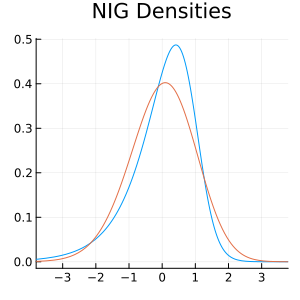

In [7]:
# NIG distribution I
λ, α, β, δ, γ = sNIG(1/2, -1/3)

plot(x->pdf(NormalInverseGaussian(λ, α, β, δ),x),xlims=(-3.8,3.8),
    size=(300,300),
    legend=:none,
    title = "NIG Densities",
    label=L"(\xi,\chi)=(1/2,-1/3)")

# NIG distribution II
λ, α, β, δ, γ = sNIG(1/8, -1/16)

p01 = plot!(x->pdf(NormalInverseGaussian(λ, α, β, δ),x),
    label=L"(\xi,\chi)=(1/8,-1/16)")

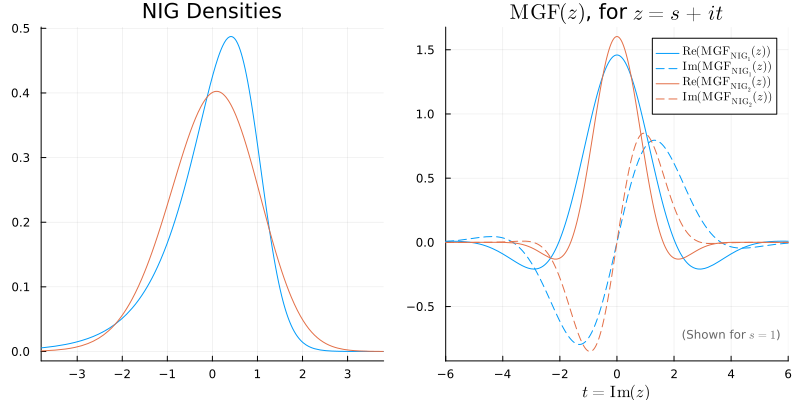

In [8]:
# MGF relevant for integration (over the line in C it is integrated over). 
# z = 1 + i*t      (s=1)
# NIG distribution I
λ, α, β, δ, γ = sNIG(1/2, -1/3)
plot(xlims=(-6,6),xlabel=L"t=\mathrm{Im}(z)",title=L"$\mathrm{MGF}(z)$, for $z=s+it$")
plot!(t->real(MGF_NIG(λ, α, β, δ, γ, 1+im*t)),label=L"\mathrm{Re}(\mathrm{MGF}_{\mathrm{NIG}_1}(z))")
plot!(t->imag(MGF_NIG(λ, α, β, δ, γ, 1+im*t)),label=L"\mathrm{Im}(\mathrm{MGF}_{\mathrm{NIG}_1}(z))",linestyle=:dash,seriescolor=1)
# NIG distribution II
λ, α, β, δ, γ = sNIG(1/8, -1/16)
plot!(t->real(MGF_NIG(λ, α, β, δ, γ, 1+im*t)),label=L"\mathrm{Re}(\mathrm{MGF}_{\mathrm{NIG}_2}(z))",seriescolor=2)
plot!(t->imag(MGF_NIG(λ, α, β, δ, γ, 1+im*t)),label=L"\mathrm{Im}(\mathrm{MGF}_{\mathrm{NIG}_2}(z))",linestyle=:dash,seriescolor=2)
annotate!(4, -0.72, text(L"(Shown for $s=1$)", color=RGB(0.4, 0.4, 0.4), 8))
p02 = plot!(size=(400,400))
plot(p01,p02, layout=(1,2),size=(800,400))

### Figure 2 — Absolute moments of the NIG (three panels)
Left: $\mathbb{E}|X|^r$ over $-0.85\le r\le 4.2$ with dots at the analytic $r=2,4$ moments. Middle: zoom near $r=4$ overlaid with 100 simulation estimates ($N=10^6$). Right: accurate decimal places of the simulation estimates.> **Note (runtime):** the middle and right panels are Monte Carlo heavy. The right-panel cell uses `K=100` (i.e. `N=10^8` draws per `r`, rescaled by $\sqrt{K}$) for a smooth curve — lower `K` for a quick run.

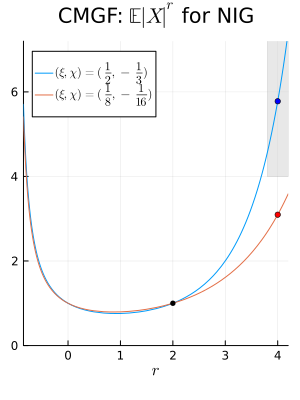

In [9]:
λ, α, β, δ, γ = sNIG(1/2, -1/3)

plot(xlims=(-0.85,4.2),ylims=(0.0,7.2),legend=:top,
    title=L"CMGF: $\mathbb{E}|X|^r$ for NIG"
)
# Define the corners of the shaded box
x_box = [3.8, 3.8, 4.2, 4.2]  # x coordinates of the rectangle
y_box = [4.0, 7.5, 7.5, 4.0]  # y coordinates of the rectangle
# Add a shaded box to the plot
plot!(x_box, y_box, fillalpha=0.5, color=:lightgray, seriestype=:shape, label=:none, linewidth=0)

plot!(r->CMGF_NIG(1,λ, α, β, δ, γ,r),
    label=L"(\xi,\chi)=(\frac{1}{2},-\frac{1}{3})",
    seriescolor=1, xlabel=L"r")

M4a = 3 + 3*(1+4*β^2/α^2)/(δ*γ)
scatter!([4], [M4a], color=:blue,markersize=3, marker=:circle,  label=:none)

λ, α, β, δ, γ = sNIG(1/8, -1/16)
plot!(r->CMGF_NIG(1,λ, α, β, δ, γ,r),seriescolor=2,
    label=L"(\xi,\chi)=(\frac{1}{8},-\frac{1}{16})")

scatter!([2], [1], color=:transparent,markersize=3, marker=:circle,  label=:none)

M4b = 3 + 3*(1+4*β^2/α^2)/(δ*γ)
scatter!([4], [M4b], color=:red,markersize=3, marker=:circle,  label=:none)
p1 = plot!(legend=:topleft,size=(300,400))

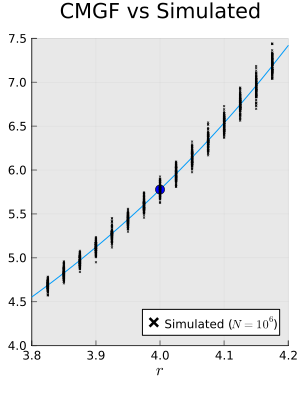

In [10]:
# A plot with simulation-based estimates included
λ, α, β, δ, γ = sNIG(1/2, -1/3)
plot(xlims=(3.8,4.2),ylims=(4.0,7.5),
    legend=:bottomright,
    size=(300,400), xlabel=L"r")

# Add a shaded box to the plot
x_box = [3.8, 3.8, 4.2, 4.2]  # x coordinates of the rectangle
y_box = [4.0, 7.5, 7.5, 4.0]  # y coordinates of the rectangle
plot!(x_box, y_box, fillalpha=0.5, color=:lightgray, seriestype=:shape, label=:none, linewidth=0)

plot!(r->CMGF_NIG(1,λ, α, β, δ, γ,r),
    title="CMGF vs Simulated",
    label=:none,#L"(\xi,\chi)=(\frac{1}{2},-\frac{1}{3})",
    seriescolor=1)

# Fourth moment 
M4a = 3 + 3*(1+4*β^2/α^2)/(δ*γ)  
scatter!([4], [M4a], color=:blue,markersize=5, marker=:circle, linewidth=0, label=:none)

# 100 Simulation-based estimates 
N = 1000000
r_values = Float64[]  # Collect all r values
y_values = Float64[]  # Collect corresponding y value
for r in 3.825:0.025:4.175
    for j in 1:100
        y = MomentSimNIG(λ, α, β, δ, γ, r, N)
        push!(r_values, r)  # Add the r value
        push!(y_values, y)  # Add the corresponding y value
    end
end
p22 = scatter!(r_values, y_values, color=:black, markersize=1, marker=:x, label=L"Simulated ($N=10^6$)")    

In [11]:
λ, α, β, δ, γ = sNIG(1/2, -1/3)
K = 5
N = K*1000000                         # simulate K mill (K>1 for extra accuracy)
rvector = 0.50:0.025:4.2
m = size(rvector)[1]
rStdDev1 = zeros(m)
rmoment1 = zeros(m)
for j = 1:m
    r = rvector[j]
    rStdDev1[j] = MomentStdDevSimNIG(λ, α, β, δ, γ, r, N)     # StdDev of simulation method
    rmoment1[j] = CMGF_NIG(1, λ, α, β, δ, γ, r)
end
λ, α, β, δ, γ = sNIG(1/8, -1/16)
rStdDev2 = zeros(m)
rmoment2 = zeros(m)
for j = 1:m
    r = rvector[j]
    rStdDev2[j] = MomentStdDevSimNIG(λ, α, β, δ, γ, r, N)
    rmoment2[j] = CMGF_NIG(1, λ, α, β, δ, γ, r)
end
rStdDev1 = rStdDev1.*√K           # rescale by √K to get accuracy for N=1mill 
rStdDev2 = rStdDev2.*√K;

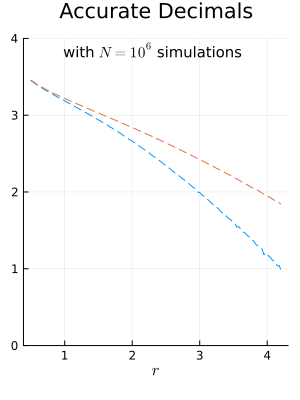

In [12]:
plot(ylims=(0,4),title="Accurate Decimals",legend=:none,size=(300,400), xlabel=L"r")
# Accurate decimals for NIG1
decimals1 = -log10.(1.0 .*  rStdDev1)
plot!(rvector,decimals1, linestyle=:dash,seriescolor=1,label=:none)
# Accurate decimals for NIG2
decimals2 = -log10.(1.0 .*  rStdDev2)
plot!(rvector,decimals2, linestyle=:dash, seriescolor=2,label=:none)
annotate!(2.3, 3.85, text(L"with $N=10^6$ simulations", :black, 10))
p21 = plot!()

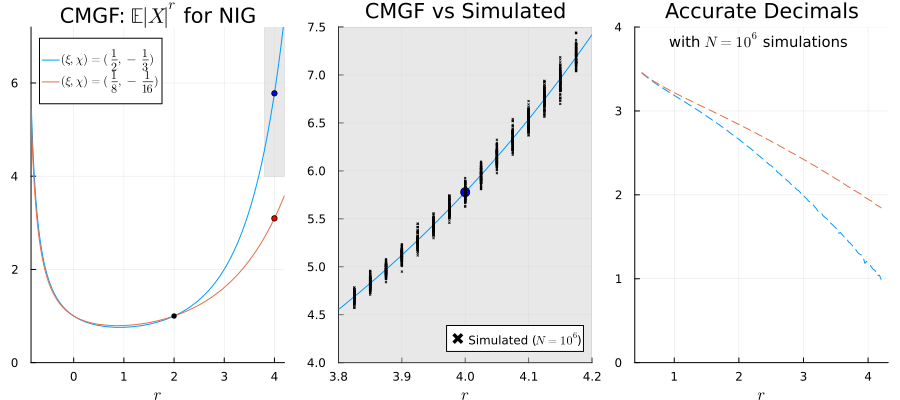

In [13]:
plot(p1,p22,p21, layout=(1,3),size=(900,400))

## Section 3.2 — Compound Poisson-Gamma (Tweedie, $1<p<2$)

# Compound Poisson-Gamma Distribution (Tweedie, 1<p<2)

The compound Poisson-Gamma distribution is defined by letting
$$
N\sim\operatorname{Poisson}(\lambda),
$$
and, conditionally on $N$, letting the severities be i.i.d.
$$
Y_1,Y_2,\ldots \sim \operatorname{Gamma}(\alpha,\beta),
$$
with shape $\alpha>0$ and scale $\beta>0$. The aggregate is
$$
X=\sum_{i=1}^{N}Y_i,
$$
with the convention $X=0$ when $N=0$. This distribution has a point mass at zero,
$$
\operatorname{P}(X=0)=e^{-\lambda},
$$
and a continuous positive component on $(0,\infty)$.

## Moment-Generating Function (MGF)

The severity MGF is
$$
M_Y(z)=\operatorname{E}\!\left(e^{zY}\right)=(1-\beta z)^{-\alpha},\qquad \operatorname{Re}(z)<1/\beta.
$$
The MGF of the compound sum $X$ is
$$
M_X(z)=\operatorname{E}\!\left(e^{zX}\right)
=\exp\!\left(\lambda\left(M_Y(z)-1\right)\right)
=\exp\!\left(\lambda\left((1-\beta z)^{-\alpha}-1\right)\right),
\qquad \operatorname{Re}(z)<1/\beta.
$$

## Tweedie parametrization

In the Tweedie exponential-dispersion parametrization $(\mu,\phi,p)$ with $\mu>0$, $\phi>0$, and $1<p<2$, the parameters map to $(\lambda,\alpha,\beta)$ as
$$
\lambda=\frac{\mu^{2-p}}{\phi(2-p)},\qquad
\alpha=\frac{2-p}{p-1},\qquad
\beta=\phi(p-1)\mu^{p-1}.
$$
This parametrization is often used for semicontinuous data because it naturally combines a point mass at zero with a continuous positive component.


In [14]:
# ------------------------------------------------------------
# Compound Poisson–Gamma (Tweedie, 1 < p < 2)
# Mapping (μ, ϕ, p)  ->  (λ, α, β)
#   N ~ Poisson(λ)
#   Y_i ~ Gamma(α, β)  (shape α, scale β)
#   X = sum_{i=1}^N Y_i
# ------------------------------------------------------------

# Parameters for Compound Poisson–Gamma in Tweedie form
# (μ, ϕ, p) with μ>0, ϕ>0, 1<p<2
function TweedieCPGamma(μ::Real, ϕ::Real, p::Real)
    @assert μ > 0 "mu must be positive"
    @assert ϕ > 0 "phi must be positive"
    @assert 1 < p < 2 "p must satisfy 1 < p < 2"

    λ = μ^(2 - p) / (ϕ * (2 - p))
    α = (2 - p) / (p - 1)
    β = ϕ * (p - 1) * μ^(p - 1)

    return (λ, α, β)
end

# MGF for Gamma(α, β) (shape α, scale β)
# Valid for Re(z) < 1/β
function MGF_Gamma(α::Real, β::Real, z)
    @assert α > 0 "alpha must be positive"
    @assert β > 0 "beta must be positive"
    return (1 - β*z)^(-α)
end

# MGF for Compound Poisson–Gamma (λ, α, β)
# M_X(z) = exp( λ * ( M_Y(z) - 1 ) )
# Uses expm1/log1p for better accuracy near z=0
function MGF_CPGamma(λ::Real, α::Real, β::Real, z)
    @assert λ ≥ 0 "lambda must be nonnegative"
    @assert α > 0 "alpha must be positive"
    @assert β > 0 "beta must be positive"

    # M_Y(z) - 1 computed stably:
    # (1 - β z)^(-α) - 1 = exp(-α*log(1-βz)) - 1
    my_minus1 = expm1(-α * log1p(-β*z))
    return exp(λ * my_minus1)
end

MGF_CPGamma (generic function with 1 method)

Because $\Pr(X=0)=e^{-\lambda}>0$, negative powers are evaluated **after conditioning on $X>0$**. The MGF of the positive component is $M_{X\mid X>0}(z)=\big(M_X(z)-e^{-\lambda}\big)/(1-e^{-\lambda})$.

In [15]:
function MGF_CPGamma_pos(λ::Real, α::Real, β::Real, z)
    ppos = 1 - exp(-λ)
    return (MGF_CPGamma(λ, α, β, z) - exp(-λ)) / ppos
end

function CMGF_CPGamma_pos(s::Real, λ::Real, α::Real, β::Real, r)
    @assert 0 < s < 1/β "need 0 < s < 1/beta"
    @assert r > -1 "need r > -1"

    abs(r) < 1e-12 && return 1.0

    g(t) = real((MGF_CPGamma_pos(λ, α, β, s+im*t) +
                 MGF_CPGamma_pos(λ, α, β, -s-im*t)) / (s+im*t)^(r+1))

    integral, err = quadgk(t -> g(t), 0, Inf, rtol=1e-8)
    return gamma(r+1) * integral / π
end

CMGF_CPGamma_pos (generic function with 1 method)

### Figure 3 — Conditional fractional moments of the compound Poisson-Gamma (two panels)
Conditional moments $\mathbb{E}[X^r\mid X>0]$ for $(\mu,\phi,p)=(1,1,1.5)$ (blue) and $(1,2,1.3)$ (red). Left: negative and small positive $r$. Right: larger $r$ on a log $y$-axis. Dots are exact conditional integer moments from cumulants. Run both panel cells, then the third to display them side by side.

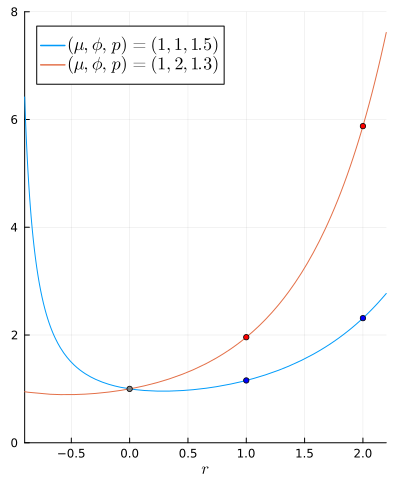

In [16]:

# ------------------------------------------------------------
# CMGF figure for Compound Poisson–Gamma: E[X^r | X>0] as a function of r
# (X ≥ 0 so |X|^r = X^r)
# ------------------------------------------------------------

# ---- Design A ----
μA, ϕA, pA = 1.0, 1.0, 1.5
λA, αA, βA = TweedieCPGamma(μA, ϕA, pA)
sA = 0.5   # must satisfy 0 < sA < 1/βA
pApos = 1 - exp(-λA)

plot(xlims=(-0.9,2.2), ylims=(0.0,8.0),
    legend=:topleft,
    legendfontsize=12,
  #    legend=:none,
  #  title=L"CMGF: $\mathbb{E}[X^r\mid X>0]$ for Compound Poisson-Gamma",
    titlefontsize=10
)

plot!(r -> CMGF_CPGamma_pos(sA, λA, αA, βA, r),
    label=L"(\mu,\phi,p)=(1,1,1.5)",
    seriescolor=1, xlabel=L"r"
)

# Mark exact conditional moments at r=2,3,4 (closed form)
m1A = αA * βA
m2A = αA * (αA + 1) * βA^2
m3A = αA * (αA + 1) * (αA + 2) * βA^3
m4A = αA * (αA + 1) * (αA + 2) * (αA + 3) * βA^4

κ1A = λA * m1A
κ2A = λA * m2A
κ3A = λA * m3A
κ4A = λA * m4A

M2A = κ2A + κ1A^2
M3A = κ3A + 3*κ2A*κ1A + κ1A^3
M4A = κ4A + 4*κ3A*κ1A + 3*κ2A^2 + 6*κ2A*κ1A^2 + κ1A^4

scatter!([1], [1/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([2], [M2A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([3], [M3A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([4], [M4A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)

# ---- Design B ----
μB, ϕB, pB = 1.0, 2.0, 1.3
λB, αB, βB = TweedieCPGamma(μB, ϕB, pB)
sB = 0.5   # must satisfy 0 < sB < 1/βB
pBpos = 1 - exp(-λB)

plot!(r -> CMGF_CPGamma_pos(sB, λB, αB, βB, r),
    seriescolor=2,
    label=L"(\mu,\phi,p)=(1,2,1.3)"
)

# Mark exact conditional moments at r=2,3,4 (closed form)
m1B = αB * βB
m2B = αB * (αB + 1) * βB^2
m3B = αB * (αB + 1) * (αB + 2) * βB^3
m4B = αB * (αB + 1) * (αB + 2) * (αB + 3) * βB^4

κ1B = λB * m1B
κ2B = λB * m2B
κ3B = λB * m3B
κ4B = λB * m4B

M2B = κ2B + κ1B^2
M3B = κ3B + 3*κ2B*κ1B + κ1B^3
M4B = κ4B + 4*κ3B*κ1B + 3*κ2B^2 + 6*κ2B*κ1B^2 + κ1B^4

scatter!([1], [1/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([2], [M2B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([3], [M3B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([4], [M4B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)

scatter!([0], [1], color=:gray, markersize=3, marker=:circle, label=:none)

p1 = plot!(size=(400,500))


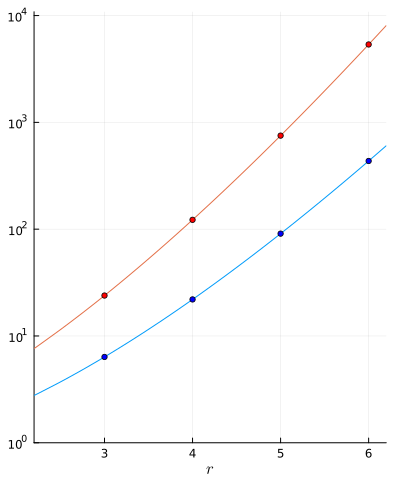

In [17]:

# ------------------------------------------------------------
# CMGF figure for Compound Poisson–Gamma: E[X^r | X>0] as a function of r
# (X ≥ 0 so |X|^r = X^r)
# ------------------------------------------------------------

# ---- Design A ----
μA, ϕA, pA = 1.0, 1.0, 1.5
λA, αA, βA = TweedieCPGamma(μA, ϕA, pA)
sA = 0.5   # must satisfy 0 < sA < 1/βA
pApos = 1 - exp(-λA)

plot(xlims=(2.2,6.2), ylims=(1,10850.0),
    yaxis=:log, 
    legend=:none,
    legendfontsize=12,
#    title=L"CMGF: $\mathbb{E}[X^r\mid X>0]$ for Compound Poisson-Gamma",
    titlefontsize=10
)

plot!(r -> CMGF_CPGamma_pos(sA, λA, αA, βA, r),
    label=L"(\mu,\phi,p)=(1,1,1.5)",
    seriescolor=1, xlabel=L"r"
)

# Mark exact conditional moments at r=2,3,4,5,6 (closed form)

# severity moments m_k = E[Y^k] for Y ~ Gamma(αA, βA)
m1A = αA * βA
m2A = αA * (αA + 1) * βA^2
m3A = αA * (αA + 1) * (αA + 2) * βA^3
m4A = αA * (αA + 1) * (αA + 2) * (αA + 3) * βA^4
m5A = αA * (αA + 1) * (αA + 2) * (αA + 3) * (αA + 4) * βA^5
m6A = αA * (αA + 1) * (αA + 2) * (αA + 3) * (αA + 4) * (αA + 5) * βA^6

# For compound Poisson: κ_n(X) = λ E[Y^n]
κ1A = λA * m1A
κ2A = λA * m2A
κ3A = λA * m3A
κ4A = λA * m4A
κ5A = λA * m5A
κ6A = λA * m6A

# Raw moments from cumulants
M2A = κ2A + κ1A^2

M3A = κ3A + 3*κ2A*κ1A + κ1A^3

M4A = κ4A + 4*κ3A*κ1A + 3*κ2A^2 + 6*κ2A*κ1A^2 + κ1A^4

M5A = κ5A + 5*κ4A*κ1A + 10*κ3A*κ2A + 10*κ3A*κ1A^2 +
      15*κ2A^2*κ1A + 10*κ2A*κ1A^3 + κ1A^5

M6A = κ6A + 6*κ5A*κ1A + 15*κ4A*κ2A + 10*κ3A^2 + 15*κ4A*κ1A^2 +
      60*κ3A*κ2A*κ1A + 20*κ3A*κ1A^3 + 15*κ2A^3 +
      45*κ2A^2*κ1A^2 + 15*κ2A*κ1A^4 + κ1A^6

scatter!([1], [1/pApos],   color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([2], [M2A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([3], [M3A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([4], [M4A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([5], [M5A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)
scatter!([6], [M6A/pApos], color=:blue, markersize=3, marker=:circle, label=:none)


# ---- Design B ----
μB, ϕB, pB = 1.0, 2.0, 1.3
λB, αB, βB = TweedieCPGamma(μB, ϕB, pB)
sB = 0.5   # must satisfy 0 < sB < 1/βB
pBpos = 1 - exp(-λB)

plot!(r -> CMGF_CPGamma_pos(sB, λB, αB, βB, r),
    seriescolor=2,
    label=L"(\mu,\phi,p)=(1,2,1.3)"
)

# Mark exact conditional moments at r=2,3,4,5,6 (closed form)

# severity moments m_k = E[Y^k] for Y ~ Gamma(αB, βB)
m1B = αB * βB
m2B = αB * (αB + 1) * βB^2
m3B = αB * (αB + 1) * (αB + 2) * βB^3
m4B = αB * (αB + 1) * (αB + 2) * (αB + 3) * βB^4
m5B = αB * (αB + 1) * (αB + 2) * (αB + 3) * (αB + 4) * βB^5
m6B = αB * (αB + 1) * (αB + 2) * (αB + 3) * (αB + 4) * (αB + 5) * βB^6

# For compound Poisson: κ_n(X) = λ E[Y^n]
κ1B = λB * m1B
κ2B = λB * m2B
κ3B = λB * m3B
κ4B = λB * m4B
κ5B = λB * m5B
κ6B = λB * m6B

# Raw moments from cumulants (Bell polynomial identities)
M2B = κ2B + κ1B^2

M3B = κ3B + 3*κ2B*κ1B + κ1B^3

M4B = κ4B + 4*κ3B*κ1B + 3*κ2B^2 + 6*κ2B*κ1B^2 + κ1B^4

M5B = κ5B + 5*κ4B*κ1B + 10*κ3B*κ2B + 10*κ3B*κ1B^2 +
      15*κ2B^2*κ1B + 10*κ2B*κ1B^3 + κ1B^5

M6B = κ6B + 6*κ5B*κ1B + 15*κ4B*κ2B + 10*κ3B^2 + 15*κ4B*κ1B^2 +
      60*κ3B*κ2B*κ1B + 20*κ3B*κ1B^3 + 15*κ2B^3 +
      45*κ2B^2*κ1B^2 + 15*κ2B*κ1B^4 + κ1B^6

scatter!([1], [1/pBpos],   color=:red, markersize=3, marker=:circle, label=:none)
scatter!([2], [M2B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([3], [M3B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([4], [M4B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([5], [M5B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)
scatter!([6], [M6B/pBpos], color=:red, markersize=3, marker=:circle, label=:none)

scatter!([0], [1], color=:gray, markersize=3, marker=:circle, label=:none)

p2 = plot!(size=(400,500))

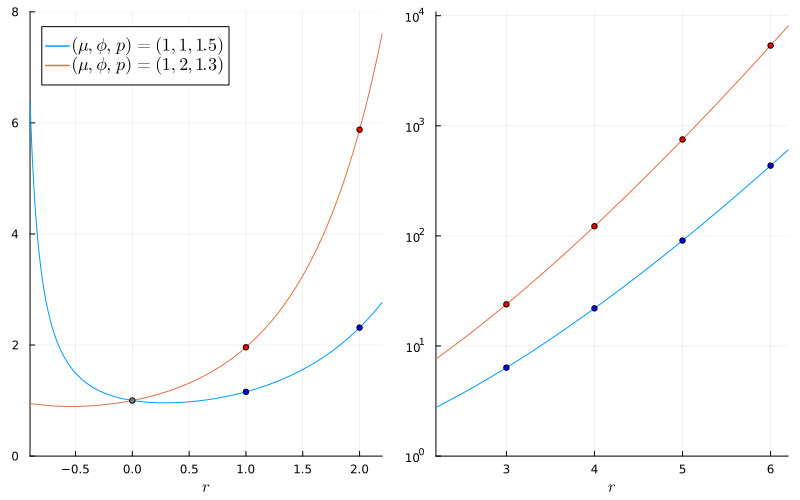

In [18]:
plot(p1,p2,layout=(1,2), size=(800,500))

# Part II — Supplementary Material

## Integrand Behavior for the NIG Distribution (Supplement figure)
Left: CMGF integrands $\operatorname{Re}\!\big[(M_X(z)+M_X(-z))/z^{r+1}\big]$ — stable across $r$. Right: density-based integrands $|x|^r f(x)$ — scale/domain vary substantially with $r$ (note the twin axis for $r=-0.5$).

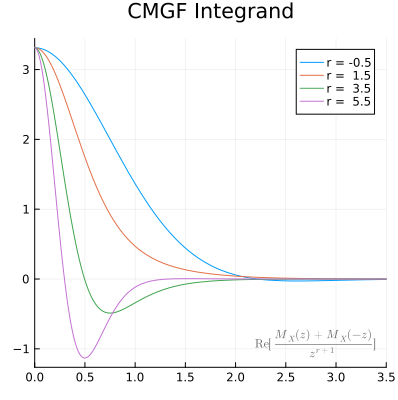

In [19]:
λ, α, β, δ, γ = sNIG(1/8, -1/16)
h(t,r) = real((MGF_NIG(λ, α, β, δ, γ, 1+im*t)+ MGF_NIG(λ, α, β, δ, γ, -1-im*t))/(1+im*t)^(r+1))
plot(size=(400,400),xlims=(0,3.5),title="CMGF Integrand")
r=-0.5; plot!(t->h(t,r),label="r = $(r)") 
#r=0.5; plot!(t->h(t,r),label="r=$(r)") 
r=1.5; plot!(t->h(t,r),label="r =  $(r)") 
#r=2.5; plot!(t->h(t,r),label="r=$(r)") 
r=3.5; plot!(t->h(t,r),label="r =  $(r)") 
r=5.5; plot!(t->h(t,r),label="r =  $(r)") 
annotate!(2.8, -0.92, text(L"\mathrm{Re}[\frac{M_X(z)+M_X(-z)}{z^{r+1}}]", color=RGB(0.4, 0.4, 0.4), 8))
p31 = plot!(size=(400,400))    

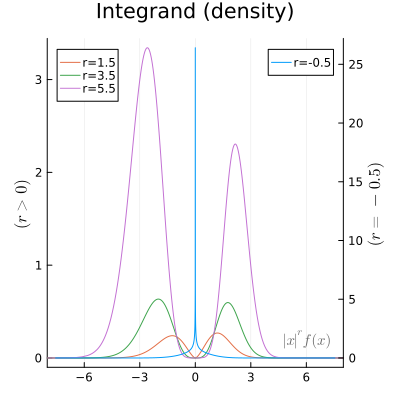

In [20]:
fxr(x,r) = pdf_NIG(λ, α, β, δ, γ, x) * abs(x)^r
plot(size=(400,400),xlims=(-8,8),legend=:topleft, ylabel=L"$(r>0)$",title="Integrand (density)")
#r =-0.5; plot!(x->fxr(x,r),label="r=$(r)") 
r = 1.5; plot!(x->fxr(x,r),label="r=$(r)", seriescolor=2) 
r = 3.5; plot!(x->fxr(x,r),label="r=$(r)", seriescolor=3) 
r = 5.5; plot!(x->fxr(x,r),label="r=$(r)", seriescolor=4) 
annotate!(6.1, 0.2, text(L"|x|^r f(x)", color=RGB(0.4, 0.4, 0.4), 10))

# Now plot for r = -0.5 using the secondary y-axis (twinx())
r = -0.5; plot!(twinx(), x -> fxr(x, r), label="r=$(r)", ylabel=L"$(r=-0.5)$", seriescolor=1,legend=:topright)
p32 = plot!(size=(400,400))

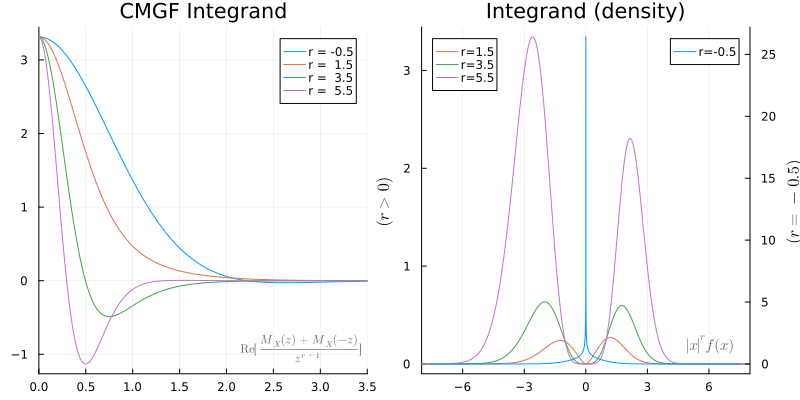

In [21]:
plot(p31,p32, layout=(1,2),size=(800,400))

## Table 1 — CMGF computation time of $\mathbb{E}|X|^r$ for $X\sim$ NIG
The `@btime` medians populate Table 1, comparing four methods: CMGF (Thm 1), $k$-th derivative of the MGF ($r=2,4$), direct density integration, and Monte Carlo ($N=10^6$). First block uses $(\xi,\chi)=(1/2,-1/3)$; the final cell repeats for $(1/8,-1/16)$.> Reported times depend on hardware; the paper records the environment used. Run all timing cells once for warm-up, then again for stable numbers.

In [22]:
N = 1_000_000   # Monte Carlo sample size used in the timing comparison

1000000

In [23]:
λ, α, β, δ, γ = sNIG(1/2, -1/3)
#Simulated moment
@btime MomentSimNIG($λ, $α, $β, $δ, $γ,-0.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 0.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 1.0, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 1.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 2.0, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 2.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 3.0, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 3.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 4.0, $N);

  36.886 ms (6 allocations: 15.28 MiB)
  36.905 ms (6 allocations: 15.28 MiB)
  25.862 ms (6 allocations: 15.28 MiB)
  36.853 ms (6 allocations: 15.28 MiB)
  26.173 ms (6 allocations: 15.28 MiB)
  36.833 ms (6 allocations: 15.28 MiB)
  25.149 ms (6 allocations: 15.28 MiB)
  36.814 ms (6 allocations: 15.28 MiB)
  27.182 ms (6 allocations: 15.28 MiB)


In [24]:
# CMGF
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ,-0.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 0.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 1.0)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 1.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 2.0)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 2.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 3.0)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 3.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 4.0);

  25.250 μs (4 allocations: 800 bytes)
  26.250 μs (4 allocations: 800 bytes)
  17.375 μs (4 allocations: 800 bytes)
  26.208 μs (4 allocations: 800 bytes)
  17.792 μs (4 allocations: 800 bytes)
  21.625 μs (4 allocations: 800 bytes)
  14.791 μs (4 allocations: 800 bytes)
  21.541 μs (4 allocations: 800 bytes)
  15.375 μs (4 allocations: 800 bytes)


In [25]:
# PDF... Integrate |x|^r*f(x)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ,-0.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 0.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 1.0)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 1.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 2.0)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 2.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 3.0)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 3.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 4.0);

  702.625 μs (8 allocations: 13.34 KiB)
  232.375 μs (6 allocations: 3.31 KiB)
  182.166 μs (6 allocations: 3.31 KiB)
  159.167 μs (6 allocations: 3.31 KiB)
  85.333 μs (4 allocations: 800 bytes)
  130.375 μs (4 allocations: 800 bytes)
  114.708 μs (4 allocations: 800 bytes)
  109.500 μs (4 allocations: 800 bytes)
  85.959 μs (4 allocations: 800 bytes)


In [26]:
# D^k MGF(0)
@btime diff_mgf($λ, $α, $β, $δ, $γ,2);
@btime diff_mgf($λ, $α, $β, $δ, $γ,4);

  168.195 ns (4 allocations: 160 bytes)
  593.458 ns (12 allocations: 512 bytes)


In [27]:
λ, α, β, δ, γ = sNIG(1/8, -1/16)
#Simulated moment
@btime MomentSimNIG($λ, $α, $β, $δ, $γ,-0.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 0.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 1.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 2.5, $N)
@btime MomentSimNIG($λ, $α, $β, $δ, $γ, 3.5, $N);
# CMGF
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ,-0.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 0.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 1.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 2.5)
@btime CMGF_NIG(1,$λ, $α, $β, $δ, $γ, 3.5);
# PDF... Integrate x^r*f(x)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ,-0.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 0.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 1.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 2.5)
@btime mPDF_NIG($λ, $α, $β, $δ, $γ, 3.5);

  39.289 ms (6 allocations: 15.28 MiB)
  38.970 ms (6 allocations: 15.28 MiB)
  38.957 ms (6 allocations: 15.28 MiB)
  38.977 ms (6 allocations: 15.28 MiB)
  38.891 ms (6 allocations: 15.28 MiB)
  22.166 μs (4 allocations: 800 bytes)
  14.625 μs (3 allocations: 256 bytes)
  14.458 μs (3 allocations: 256 bytes)
  18.041 μs (4 allocations: 800 bytes)
  18.000 μs (4 allocations: 800 bytes)
  353.291 μs (8 allocations: 13.34 KiB)
  126.208 μs (6 allocations: 3.31 KiB)
  87.167 μs (6 allocations: 3.31 KiB)
  67.667 μs (4 allocations: 800 bytes)
  62.750 μs (4 allocations: 800 bytes)


## Table 2 — Numerical verification of the parabolic representation ($X\sim\chi^2_8$, $s=0.1$)
Reproduces Table 2: the parabolic contour $z=\sqrt{s}+it$ matches the closed-form $\chi^2_8$ fractional moments to machine precision. `limit` rows use the theorem at $r=-m+10^{-6}$ near the $\Gamma(r+1)$ poles; `log` rows use the pole-free logarithmic formula (Corollary) at exact negative integers.

In [28]:
using QuadGK
using SpecialFunctions
using Printf

# ------------------------------------------------------------
# Chi-square(ν) MGF and exact fractional moments
# X ~ χ²_ν = Gamma(ν/2, 2)
# ------------------------------------------------------------

function MGF_chisq(ν::Real, z)
    @assert ν > 0 "nu must be positive"
    return (1 - 2z)^(-ν/2)
end

function true_moment_chisq(ν::Real, r::Real)
    @assert r > -ν/2 "moment exists only for r > -nu/2"
    return 2.0^r * gamma(ν/2 + r) / gamma(ν/2)
end

# ------------------------------------------------------------
# Parabolic CMGF moment integral
# Uses z = sqrt(s) + it
# ------------------------------------------------------------

function PMT_chisq(ν::Real, s::Real, r::Real; rtol=1e-10)
    @assert ν > 0 "nu must be positive"
    @assert 0 < s < 1/2 "need 0 < s < 1/2 for χ² MGF on the parabolic contour"
    @assert r > -ν/2 "moment exists only for r > -nu/2"

    a = sqrt(s)

    g(t) = begin
        z = a + im*t
        real(MGF_chisq(ν, z^2) / z^(2r + 1))
    end

    integral, err = quadgk(g, 0, Inf; rtol=rtol)
    return 2 * gamma(r + 1) * integral / π
end

# ------------------------------------------------------------
# Pole-free parabolic formula for negative integer moments
# Uses the logarithmic contour formula at r = -m, m = 1,2,...
#
# E[X^(-m)] =
#   4*(-1)^m/(π*(m-1)!) * ∫_0^∞ Re[log(z) z^(2m-1) M_X(z^2)] dt
# ------------------------------------------------------------

function PMT_chisq_negint(ν::Real, s::Real, m::Integer; rtol=1e-10)
    @assert ν > 0 "nu must be positive"
    @assert 0 < s < 1/2 "need 0 < s < 1/2 for χ² MGF on the parabolic contour"
    @assert m ≥ 1 "m must be a positive integer"
    @assert m < ν/2 "negative integer moment E[X^(-m)] exists only for m < nu/2"

    a = sqrt(s)

    g(t) = begin
        z = a + im*t
        real(log(z) * z^(2m - 1) * MGF_chisq(ν, z^2))
    end

    integral, err = quadgk(g, 0, Inf; rtol=rtol)
    return 4 * (-1)^m * integral / (π * factorial(m - 1))
end

# ------------------------------------------------------------
# Numerical verification
# ------------------------------------------------------------

ν = 8.0
s = 0.1
ϵ = 1e-6

# Each row is either:
# (:pmt, r)          ordinary parabolic formula
# (:negint, -m, m)   pole-free logarithmic formula at r = -m
rows = [
    (:pmt,    -3.5),
    (:negint, -3.0, 3),
    (:pmt,    -3.0 + ϵ),
    (:pmt,    -2.5),
    (:negint, -2.0, 2),
    (:pmt,    -2.0 + ϵ),
    (:pmt,    -1.5),
    (:negint, -1.0, 1),
    (:pmt,    -1.0 + ϵ),
    (:pmt,    -0.5),
    (:pmt,     0.5),
    (:pmt,     1.0),
    (:pmt,     2.0),
    (:pmt,     3.0)
]

println("χ² verification: ν = $ν, s = $s")
println("Moment exists for r > $(-ν/2)")
println()

@printf("%16s %10s %22s %22s %14s\n", "r", "method", "PMT", "true", "rel.err")
println("-"^92)

for row in rows
    if row[1] == :pmt
        r = row[2]
        m_pmt = PMT_chisq(ν, s, r)
        method = "limit"
    else
        r = row[2]
        m = row[3]
        m_pmt = PMT_chisq_negint(ν, s, m)
        method = "log"
    end

    m_true = true_moment_chisq(ν, r)
    relerr = abs(m_pmt - m_true) / abs(m_true)

    @printf("%16.6f %10s %22.15e %22.15e %14.3e\n",
            r, method, m_pmt, m_true, relerr)
end

χ² verification: ν = 8.0, s = 0.1
Moment exists for r > -4.0

               r     method                    PMT                   true        rel.err
--------------------------------------------------------------------------------------------
       -3.500000      limit  2.611071119407293e-02  2.611071119407292e-02      1.329e-16
       -3.000000        log  2.083333333333322e-02  2.083333333333333e-02      5.329e-15
       -2.999999      limit  2.083333574873437e-02  2.083333574859052e-02      6.905e-12
       -2.500000      limit  2.611071119407292e-02  2.611071119407292e-02      0.000e+00
       -2.000000        log  4.166666666666709e-02  4.166666666666666e-02      1.033e-14
       -1.999999      limit  4.166671316371828e-02  4.166671316385254e-02      3.222e-12
       -1.500000      limit  7.833213358221879e-02  7.833213358221877e-02      1.772e-16
       -1.000000        log  1.666666666666667e-01  1.666666666666667e-01      1.665e-16
       -0.999999      limit  1.6666693598057

In [29]:
# Environment summary (clean version/hardware printout;
# avoids versioninfo()'s long DYLD_* environment dump)
using Pkg

println("Julia version : ", VERSION)
println("OS / platform : ", Sys.KERNEL, " (", Sys.MACHINE, ")")
println("CPU           : ", Sys.cpu_info()[1].model)
println("Cores         : ", Sys.CPU_THREADS, " logical")
println("Word size     : ", Sys.WORD_SIZE, "-bit")
println()

versions = Dict(dep.name => dep.version for (_, dep) in Pkg.dependencies())
println("Key package versions:")
for name in ["Distributions", "Plots", "QuadGK", "SpecialFunctions", "ForwardDiff", "BenchmarkTools"]
    haskey(versions, name) && versions[name] !== nothing &&
        println("  ", rpad(name, 16), "v", versions[name])
end

Julia version : 1.12.6
OS / platform : Darwin (arm64-apple-darwin24.0.0)
CPU           : Apple M2 Max
Cores         : 8 logical
Word size     : 64-bit

Key package versions:
  Distributions   v0.25.127
  Plots           v1.41.6
  QuadGK          v2.11.3
  SpecialFunctionsv2.8.0
  ForwardDiff     v1.4.1
  BenchmarkTools  v1.8.0
